In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
from IPython.display import display

In [2]:
trial_usage_summary = pd.read_csv('/kaggle/input/datasets/mam4182/nextwave-dataset/trial_usage_summary.csv')
segment_retention = pd.read_csv('/kaggle/input/datasets/mam4182/nextwave-dataset/segment_retention.csv')
landing_event_log = pd.read_csv('/kaggle/input/datasets/mam4182/nextwave-dataset/landing_event_log.csv')
funnel_summary = pd.read_csv('/kaggle/input/datasets/mam4182/nextwave-dataset/funnel_summary.csv')
customer_feedback_summary = pd.read_csv('/kaggle/input/datasets/mam4182/nextwave-dataset/customer_feedback_summary.csv')
channel_performance = pd.read_csv('/kaggle/input/datasets/mam4182/nextwave-dataset/channel_performance.csv')

In [3]:
from IPython.display import display

# 데이터프레임 리스트와 이름 설정
dfs = [
    ("Trial_Usage", trial_usage_summary),
    ("Segment_Retention", segment_retention),
    ("Landing_Event_Log", landing_event_log),
    ("Funnel_Summary", funnel_summary),
    ("Customer_Feedback_Summary", customer_feedback_summary),
    ("Channel_Performance", channel_performance)
]

for title, df in dfs:
    print(f" [ {title} ]")
    display(df)
    print("\n")

 [ Trial_Usage ]


,기능,기능 사용자 수,평균 사용 횟수,유료 전환율
0,일정관리,2840,8.2,24.0%
1,협업메모,1920,4.1,17.5%
2,팀 초대,740,2.7,36.0%
3,알림 자동화,510,1.9,41.0%




 [ Segment_Retention ]


,고객 유형,4주차 유지율
0,대학생,21%
1,직장인 개인사용자,38%
2,프리랜서,34%
3,소규모 팀 사용자,49%




 [ Landing_Event_Log ]


...

,month,방문 유저 수,회원가입 유저,무료 체험 유저,유료 결제 유저,한달 유지
0,1월,52000,4420,2431,972,1945
1,2월,54000,4212,2274,880,1801
2,3월,55500,3885,1942,731,1492
3,4월,56000,3528,1623,584,1176




 [ Customer_Feedback_Summary ]


,이슈 유형,비중
0,가입 절차 번거로움,28%
1,무료체험 가치 체감 부족,24%
2,요금제 이해 어려움,18%
3,팀 기능 이해 부족,16%
4,알림 과다,14%




 [ Channel_Performance ]


,month,유입 채널,방문자 수,회원가입 전환율,무료체험 시작률,유료 전환율
0,4월,검색,18000,8.1%,5.0%,1.8%
1,4월,SNS,17500,4.3%,2.1%,0.7%
2,4월,자연 유입,11000,9.5%,6.4%,2.2%
3,4월,지인 추천,9500,10.2%,7.1%,2.8%


## 개념 정리: `이탈률`

### **이탈률 = (직전단계 유저수 - 현재단계 유저수)/직전단계 유저수**

### --> Landing_Event_Log의 첫 단계인 랜딩페이지 진입 단계의 이탈률은 계산 할 수 없음.

In [4]:
# 데이터 파악:
# 제공된 데이터는 크기가 작아 눈으로 직접 확인 가능
# 결측치나 문자 데이터를 골라내는 코드 작성할 필요 없음(오버 엔지니어링)

# 확인 결과:
# Landing_Event_Log의 랜딩페이지 진입에 '-' 비정형 결측치 값이 존재하는데,
# 이는 위에서 개념 설명한 것처럼 구할 수 없는 값임.
# 또한 % 등의 값들은 연산을 위해서 소수점으로 변환할 필요 있음

In [5]:
for name, df in dfs:
    for col in df.columns:
        if df[col].astype(str).str.contains('%').any():
            # % 제거
            temp_col = df[col].astype(str).str.replace('%', '', regex=False)
            # 숫자로 변환 (변환 안 되는 '-'은 NaN 처리)
            # 100으로 나누어 소수점 변환
            df[col] = pd.to_numeric(temp_col, errors='coerce') / 100
            
            print(f"[{name}]의 '{col}' 컬럼 변환 완료\n")

[Trial_Usage]의 '유료 전환율' 컬럼 변환 완료

[Segment_Retention]의 '4주차 유지율' 컬럼 변환 완료

[Landing_Event_Log]의 '이탈률' 컬럼 변환 완료

[Customer_Feedback_Summary]의 '비중' 컬럼 변환 완료

[Channel_Performance]의 '회원가입 전환율' 컬럼 변환 완료

[Channel_Performance]의 '무료체험 시작률' 컬럼 변환 완료

[Channel_Performance]의 '유료 전환율' 컬럼 변환 완료



In [6]:
for title, df in dfs:
    print(f" [ {title} ]")
    display(df)
    print("\n")

 [ Trial_Usage ]


,기능,기능 사용자 수,평균 사용 횟수,유료 전환율
0,일정관리,2840,8.2,0.240
1,협업메모,1920,4.1,0.175
2,팀 초대,740,2.7,0.360
3,알림 자동화,510,1.9,0.410




 [ Segment_Retention ]


,고객 유형,4주차 유지율
0,대학생,0.21
1,직장인 개인사용자,0.38
2,프리랜서,0.34
3,소규모 팀 사용자,0.49




 [ Landing_Event_Log ]


...

,month,방문 유저 수,회원가입 유저,무료 체험 유저,유료 결제 유저,한달 유지
0,1월,52000,4420,2431,972,1945
1,2월,54000,4212,2274,880,1801
2,3월,55500,3885,1942,731,1492
3,4월,56000,3528,1623,584,1176




 [ Customer_Feedback_Summary ]


,이슈 유형,비중
0,가입 절차 번거로움,0.28
1,무료체험 가치 체감 부족,0.24
2,요금제 이해 어려움,0.18
3,팀 기능 이해 부족,0.16
4,알림 과다,0.14




 [ Channel_Performance ]


,month,유입 채널,방문자 수,회원가입 전환율,무료체험 시작률,유료 전환율
0,4월,검색,18000,0.081,0.050,0.018
1,4월,SNS,17500,0.043,0.021,0.007
2,4월,자연 유입,11000,0.095,0.064,0.022
3,4월,지인 추천,9500,0.102,0.071,0.028


In [7]:
# %형식 데이터 가공 가능한 수치형 데이터로 변환 완료
# NaN값은 미팅에서 어떤 방식으로 처리 할 건지 논의 예정

# 교차 검증 필요

In [8]:
# =================================
# 교차검증 실시
# =================================

In [9]:
# 데이터 정합성 검증 및 교차 검증 (Cross-Validation)
# 퍼널 데이터 내 논리적 일관성 검증 (상위 단계 > 하위 단계)
print("[검증 1] Funnel Summary 수치 흐름")
funnel_steps = ['방문 유저 수', '회원가입 유저', '무료 체험 유저']
logic_error_found = False

for i in range(len(funnel_steps) - 1):
    # 상위 단계보다 하위 단계 유저가 많은 행 필터링
    invalid_rows = funnel_summary[funnel_summary[funnel_steps[i]] < funnel_summary[funnel_steps[i+1]]]
    if not invalid_rows.empty:
        print(f"논리 오류: '{funnel_steps[i]}'보다 '{funnel_steps[i+1]}'가 많은 데이터가 발견됨!")
        display(invalid_rows)
        logic_error_found = True

if not logic_error_found:
    print("모든 월에서 유저 수가 단계별로 정상적으로 감소함 (논리 일치)")

[검증 1] Funnel Summary 수치 흐름
모든 월에서 유저 수가 단계별로 정상적으로 감소함 (논리 일치)


In [10]:
# 테이블 간 교차 검증 (4월 데이터 기준)
print("\n[검증 2] 테이블 간 수치 정합성 (Cross-Table Check)")

# Funnel_Summary vs Landing_Event_Log (4월 가입 완료자 수 대조)
try:
    f_signup = funnel_summary[funnel_summary['month'] == '4월']['회원가입 유저'].values[0]
    l_signup = landing_event_log[landing_event_log['단계'] == '가입 완료']['사용자 수'].values[0]

    if f_signup == l_signup:
        print(f"가입자 수 일치: 퍼널({f_signup}명) == 랜딩로그({l_signup}명)")
    else:
        print(f"가입자 수 불일치: 퍼널({f_signup}) vs 랜딩로그({l_signup})")
        print(f"    -> 차이: {abs(f_signup - l_signup)}명")
except:
    print("가입자 수 비교 중 데이터 누락 확인 필요")

# Funnel_Summary vs Channel_Performance (4월 총 방문자 수 대조)
try:
    f_visit = funnel_summary[funnel_summary['month'] == '4월']['방문 유저 수'].values[0]
    c_visit_sum = channel_performance['방문자 수'].sum()

    if f_visit == c_visit_sum:
        print(f"방문자 수 일치: 퍼널 합계({f_visit}명) == 채널별 합계({c_visit_sum}명)")
    else:
        print(f"방문자 수 불일치: 퍼널({f_visit}) vs 채널합계({c_visit_sum})")
        print(f"    -> 차이: {abs(f_visit - c_visit_sum)}명")
except:
    print("방문자 수 비교 중 데이터 누락 확인 필요")


[검증 2] 테이블 간 수치 정합성 (Cross-Table Check)
가입자 수 일치: 퍼널(3528명) == 랜딩로그(3528명)
방문자 수 일치: 퍼널 합계(56000명) == 채널별 합계(56000명)


In [11]:
# 데이터 결측치(NaN) 최종 점검
print("\n[검증 3] 전체 데이터 결측치 현황")
for name, df in dfs:
    nan_count = df.isnull().sum().sum()
    status = "점검 필요" if nan_count > 0 else "정상"
    print(f" - {name}: {nan_count}개의 결측치 발견 ({status})")


[검증 3] 전체 데이터 결측치 현황
 - Trial_Usage: 0개의 결측치 발견 (정상)
 - Segment_Retention: 0개의 결측치 발견 (정상)
 - Landing_Event_Log: 1개의 결측치 발견 (점검 필요)
 - Funnel_Summary: 0개의 결측치 발견 (정상)
 - Customer_Feedback_Summary: 0개의 결측치 발견 (정상)
 - Channel_Performance: 0개의 결측치 발견 (정상)


In [12]:
# 교차검증 결과
# 퍼널 데이터 내 단계별 논리적 일관성 이상없음
# 테이블 간 데이터 대조 결과 이상없음
# 데이터 결측치 점검 간 Landing_Event_Log 내 결측치 발견 (논의 후 처리 예정)

# 0으로 대체하는 것으로 결정. 계산 과정에서 0값으로 인해 오류가 발생할 경우에는
# 코드를 수정하는 방식으로 대처. 또한 이탈률을 0% 가정하는 것이 분석 흐름상 무리가 없으며,
# 라인 차트 등 시각화 과정에서 적절할 것이라 판단.

In [13]:
# 결측치 0으로 대체
landing_event_log = landing_event_log.fillna(0)

dfs = [
    ("Trial_Usage", trial_usage_summary),
    ("Segment_Retention", segment_retention),
    ("Landing_Event_Log", landing_event_log),
    ("Funnel_Summary", funnel_summary),
    ("Customer_Feedback_Summary", customer_feedback_summary),
    ("Channel_Performance", channel_performance)
]

print("전처리 완료")

# 확인
print("\n결측치 데이터 최종 점검")
for name, df in dfs:
    nan_count = df.isnull().sum().sum()
    status = "점검 필요" if nan_count > 0 else "정상"
    print(f" - {name}: {nan_count}개의 결측치 발견 ({status})")

전처리 완료

결측치 데이터 최종 점검
 - Trial_Usage: 0개의 결측치 발견 (정상)
 - Segment_Retention: 0개의 결측치 발견 (정상)
 - Landing_Event_Log: 0개의 결측치 발견 (정상)
 - Funnel_Summary: 0개의 결측치 발견 (정상)
 - Customer_Feedback_Summary: 0개의 결측치 발견 (정상)
 - Channel_Performance: 0개의 결측치 발견 (정상)


In [14]:
# ====================================================================
# trial_usage_summary, segment_retention, landing_event_log 데이터 탐색
# ====================================================================

컬럼 의미 정리  
  
`기능`: 유저를 유입시키는 입구 역할  
`기능 사용자 수`: 해당 기능의 대중성과 시장성을 의미(모객력)  
`평균 사용 횟수`: 유저의 활동성을 의미  
`유료 전환율`: 해당 기능의 가치를 의미(수익화 동력)

In [15]:
# 한글 세팅
!sudo apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib  # 이전 폰트 캐시 삭제
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)




The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 138 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (22.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
Selecting previously unselected package fonts-nanum.
(Reading database ... 120314 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [16]:
# 실제 유료 전환 유저 수 확인
trial_usage_summary['결제 유저 수'] = (trial_usage_summary['기능 사용자 수'] * trial_usage_summary['유료 전환율']).round(0).astype(int)

display(trial_usage_summary[['기능', '기능 사용자 수', '평균 사용 횟수', '유료 전환율', '결제 유저 수']])

,기능,기능 사용자 수,평균 사용 횟수,유료 전환율,결제 유저 수
0,일정관리,2840,8.2,0.240,682
1,협업메모,1920,4.1,0.175,336
2,팀 초대,740,2.7,0.360,266
3,알림 자동화,510,1.9,0.410,209


/tmp/ipykernel_16/1465231792.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='기능', y='기능 사용자 수', data=df, ax=axlist[0], palette='Blues_r')
/tmp/ipykernel_16/1465231792.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='기능', y='평균 사용 횟수', data=df, ax=axlist[1], palette='Greens_r')
/tmp/ipykernel_16/1465231792.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='기능', y=df['유료 전환율'] * 100, data=df, ax=axlist[2], palette='Reds_r')
/tmp/ipykernel_16/1465231792.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is dep

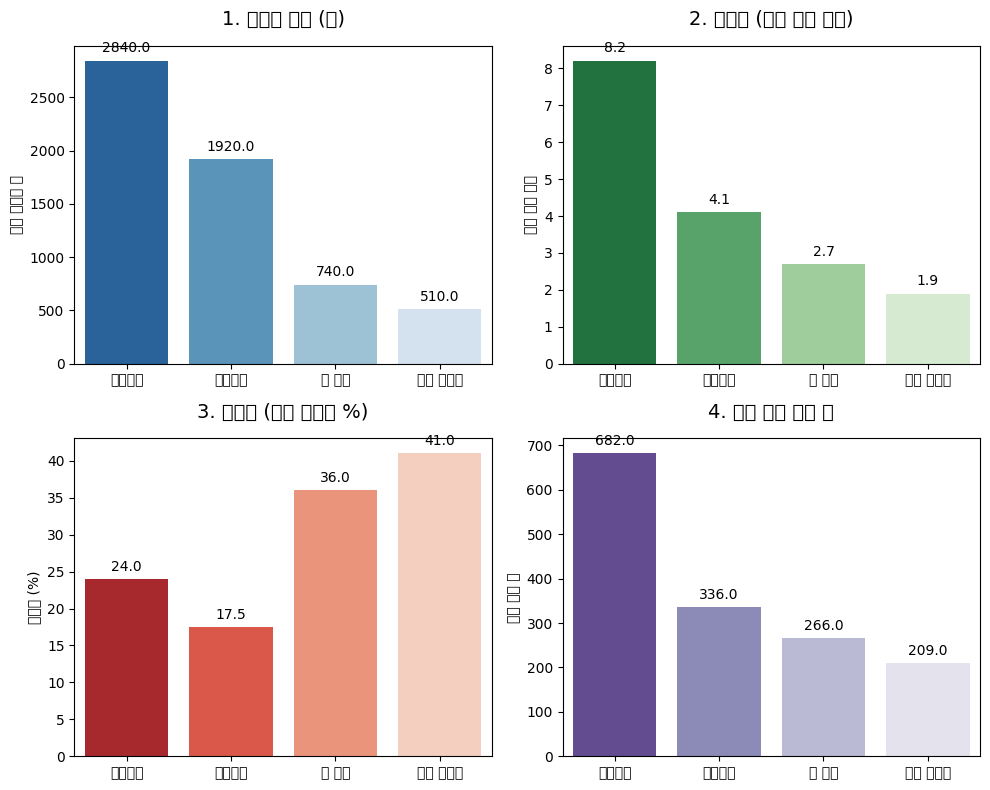

In [17]:
# trial_usage_summary 데이터 시각화
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axlist = axes.flatten()

df = trial_usage_summary

# 사용자 규모
sns.barplot(x='기능', y='기능 사용자 수', data=df, ax=axlist[0], palette='Blues_r')
axlist[0].set_title('1. 사용자 규모 (명)', fontsize=14, pad=15)

# 활동성
sns.barplot(x='기능', y='평균 사용 횟수', data=df, ax=axlist[1], palette='Greens_r')
axlist[1].set_title('2. 활동성 (평균 사용 횟수)', fontsize=14, pad=15)

# 수익성
sns.barplot(x='기능', y=df['유료 전환율'] * 100, data=df, ax=axlist[2], palette='Reds_r')
axlist[2].set_title('3. 수익성 (유료 전환율 %)', fontsize=14, pad=15)
axlist[2].set_ylabel('전환율 (%)')

# 결제 유저 수
sns.barplot(x='기능', y='결제 유저 수', data=df, ax=axlist[3], palette='Purples_r')
axlist[3].set_title('4. 유료 전환 유저 수', fontsize=14, pad=15)

for ax in axlist:
    ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

### 분석 결과

1. `일정관리`    
    * 특성: 일정은 수시로 확인하고 수정해야 하므로 평균 사용 횟수(8.2회)가 높은 서비스로 보임.

    * 분석
      - 사용자 규모(2,840명)와 결제 유저(682명)를 보면, 일정관리 서비스가 현재 수익의 중심일 것으로 예상.
      - 확실한 분석을 위해서는 `각 서비스 별 유료 전환 비용`도 고려할 필요가 있음.

    * 인사이트
      - 유료 전환율이 24%인데, 이는 기능 이용자 수를 고려할떄 낮은 편으로 보이지 않으나 `유사 서비스의 유료 전환율` 확인 필요함.
      - 유료 전환율을 향상 시키면 수익 증가의 가장 효과적인 상품이 될 것으로 보임

2. `알림 자동화`
    * 특성: 한 번 설정하면 유저가 들어올 일이 없는(평균 사용 횟수(1.9회)) 서비스로 보임.

    * 분석: 유료 전환율(41%) 1위. 유저의 알림 자동화 기능에 대한 만족도가 매우 높음을 알 수 있음.

    * 인사이트: 성능은 뛰어나나, `홍보 또는 대중성` 등의 원인으로 유저의 `유입이 부족`한 기능으로 보임.

3. `협업메모`
    * 특성: 일정관리처럼 유저가 직접 기록하는 노동적 성격. 사용 횟수(4.1회)가 중간 이상임.

    * 분석
      - 기능 사용자 수가 두번째로 높은 것을 볼때, 기능의 `대중성은 충분`하다고 보임.
      - 하지만, 전환율(17.5%)이 가장 낮음. 유저는 결제할 만큼의 가치를 느끼지 못했을 것.

    * 인사이트: 기능 대비 유료 결제 `비용이 비싸다고` 느꼈을 것으로 예상.

4. `팀 초대`
    * 특성: 알림 자동화처럼 횟수(2.7회)는 적지만, 전환율(36%)은 높음

    * 분석: 유료 전환율(36%) 2위. 유저의 만족도가 높음을 알 수 있음.

    * 인사이트
      - 알림 자동화처럼 `홍보 또는 대중성` 등의 원인으로 유저의 `유입이 부족`한 기능으로 보임.
      - 혼자 쓰는 서비스가 아닌, `함께 쓰는 플랫폼`이므로, 서비스의 이탈률이 낮을 것으로 예상.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

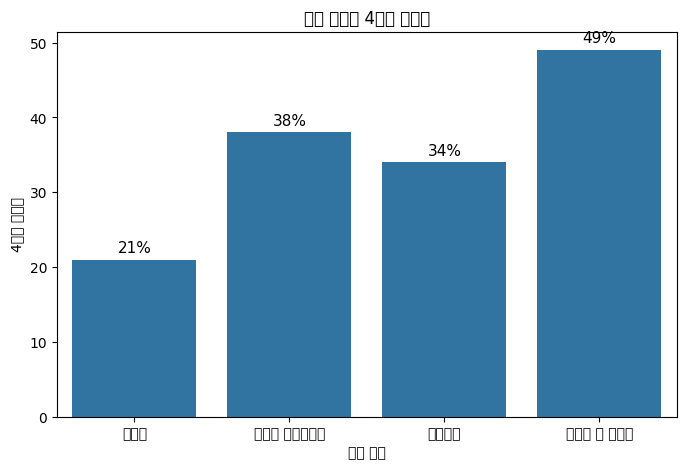

In [18]:
# segment_retention 데이터 시각화
plt.figure(figsize=(8,5))
ax = sns.barplot(x='고객 유형', y=segment_retention['4주차 유지율']*100, data=segment_retention)
ax.set_title("고객 유형별 4주차 유지율")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=11)
    
plt.show()

### 개념정리: 4주차 유지율
* 일반적으로 유지율은 회원가입 또는 첫 방문 시점을 기준으로 함: 유저가 서비스의 가치를 발견하고 지속적으로 사용하는가
* 4주차의 의미
  - 고객의 서비스 이용이 습관으로 자리 잡는 기간
  - 대부분의 비즈니스는 한 달 단위로 성과 측정
  - 4주차에 남은 유저는 다음 달에도 서비스를 이용할 확률이 높음
  - 체험 기간 종료 시점(해당 부분은 더 확인 필요)
    - 보통 많은 서비스가 1-2주의 무료 체험 기간 제공
    - 무료 체험이 끝난 뒤에도 계속 사용하고 결제까지 이어졌는가

### 분석 결과

1. `각 사용자 유형의 비율`을 확인할 필요 있음

2. 소규모 팀 사용자

   * 분석
     - 4주차 유지율 49%로 1위
     - `협업 메모`와 `팀 초대` 기능을 주로 사용하는 집단일 가능성 있음
     - 서비스에 대한 의존도 높음

   * 인사이트: 가장 안정적인 매출원, 소규모 팀 유형의 고객 규모를 늘리는 것이 KPI 상승의 핵심일 것

4. 직장인 개인사용자 / 프리랜서

   * 분석
     - 개인적으로 사용하는 서비스의 가치를 어느정도 인정하지만, 소규모팀만큼의 이탈장벽은 없음
     - `일정 관리`, `알림 자동화` 같은 개인의 생산성을 높여주는 기능에 집중할 가능성 있음

   * 인사이트: 소규모 팀처럼 `팀 단위로 확장(B2B 전환)`하도록 유도하는 전략 고려
  
5. 대학생

   * 분석
      - 유지율 21%로 가장 낮음
      - 서비스에 대한 `충성도가 가장 낮은` 집단
      - 과제나 시험 기간 준비를 위해서 잠깐 사용하는 `체리피커`로 보임
  
   * 인사이트: 당장의 수익률은 낮지만, `대중적 인지도`를 높이는 역할을 할 수 있음
  
6. 핵심 예상 KPI 저하 요인 분석

    * `소규모 팀`은 협업 메모를 주로 사용할 것으로 예상 되지만, 협업 메모의 전환율을 높지 않음. 즉, 소규모 팀의 유지율은 높지만, 서비스 내 `비중이 낮을 가능성`이 큼. 협업 메모 기능 유저의 대부분은 대학생이나 개인 사용자인 것으로 예상됨. -> `유저 타겟팅 미스매치`
  
    * `직장인 개인사용자 / 프리랜서` 집단이 일정 관리와 알림 자동화를 주로 사용할 것으로 예상하지만, 그렇다면 두 기능 사이에 규모 차이가 크게 벌어지는가. 즉, 일정 관리 같은 기본 기능에서 `알림 자동화`라는 고급 기능으로 넘어가는데 `피로`를 느끼고 이탈했을 가능성. 또한, 알림 자동화의 전환율은 매우 높으므로, 해당 기능으로 넘어가는 유저는 `충성도가 높은 고객`으로 볼 수 있음
  
    * `대학생`은 사용자 규모는 크게 차지할 것으로 예상 되지만, 유지율이 매우 낮음.
  
    * 즉, `협업을 안 하는 유저(대학생, 개인)에게 협업 기능을 권유하느라 리소스를 낭비 했거나`, `직장인들이 알림 자동화로 넘어가지 전에 이탈하거나`, `대학생 유입이 늘어나 KPI를 저하시켰을 가능성 있음`.

/tmp/ipykernel_16/3002697468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='단계', y='사용자 수', data=landing_event_log, ax=ax1, palette='Blues_r', alpha=0.7)
/tmp/ipykernel_16/3002697468.py:27: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3002697468.py:27: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3002697468.py:27: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3002697468.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3002697468.py:27: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.


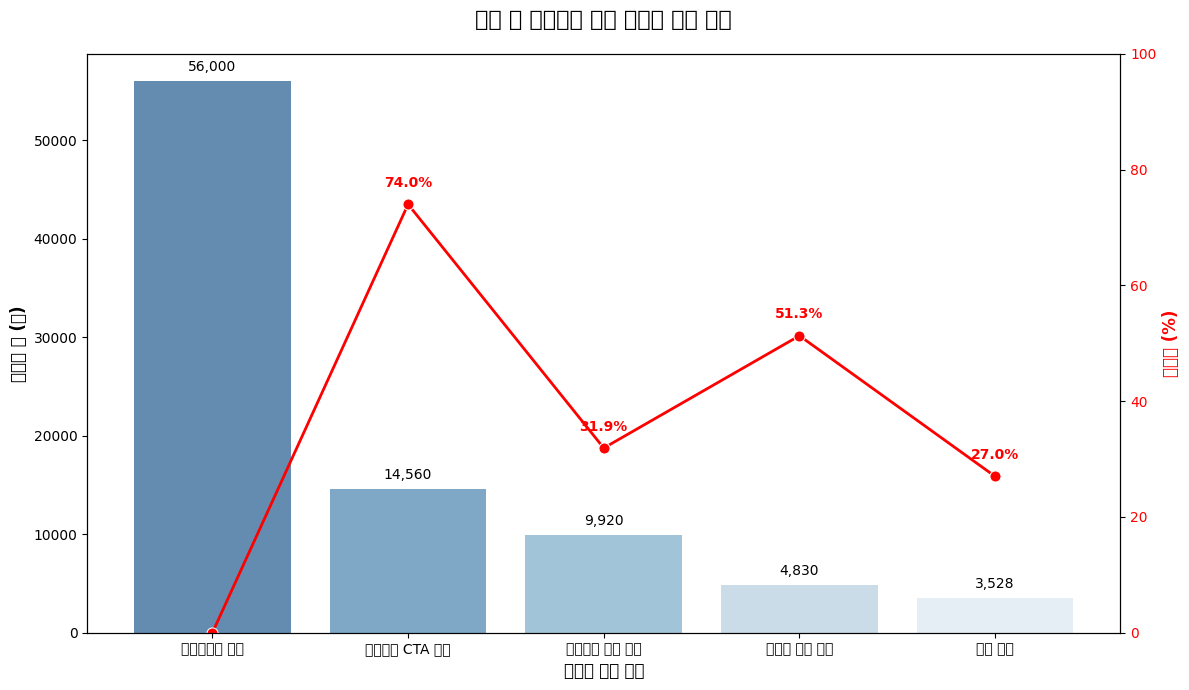

In [19]:
# landing_event_log 데이터 시각화
# 데이터 준비
fig, ax1 = plt.subplots(figsize=(12, 7))

# 사용자 수
sns.barplot(x='단계', y='사용자 수', data=landing_event_log, ax=ax1, palette='Blues_r', alpha=0.7)
ax1.set_ylabel('사용자 수 (명)', fontsize=12, fontweight='bold')
ax1.set_xlabel('서비스 가입 단계', fontsize=12)
ax1.set_title('랜딩 및 회원가입 단계 이벤트 로그 요약', fontsize=16, pad=20)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# 이탈률
ax2 = ax1.twinx()
sns.lineplot(x='단계', y=landing_event_log['이탈률'] * 100, data=landing_event_log, ax=ax2, color='red', marker='o', linewidth=2, markersize=8)
ax2.set_ylabel('이탈률 (%)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)

for i, val in enumerate(landing_event_log['이탈률'] * 100):
    if val > 0: # 0단계 이탈률 제외
        ax2.text(i, val + 3, f'{val:.1f}%', color='red', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# ====================================================================
# funnel_summary, customer_feedback_summary, channel_performance 데이터 탐색
# ====================================================================

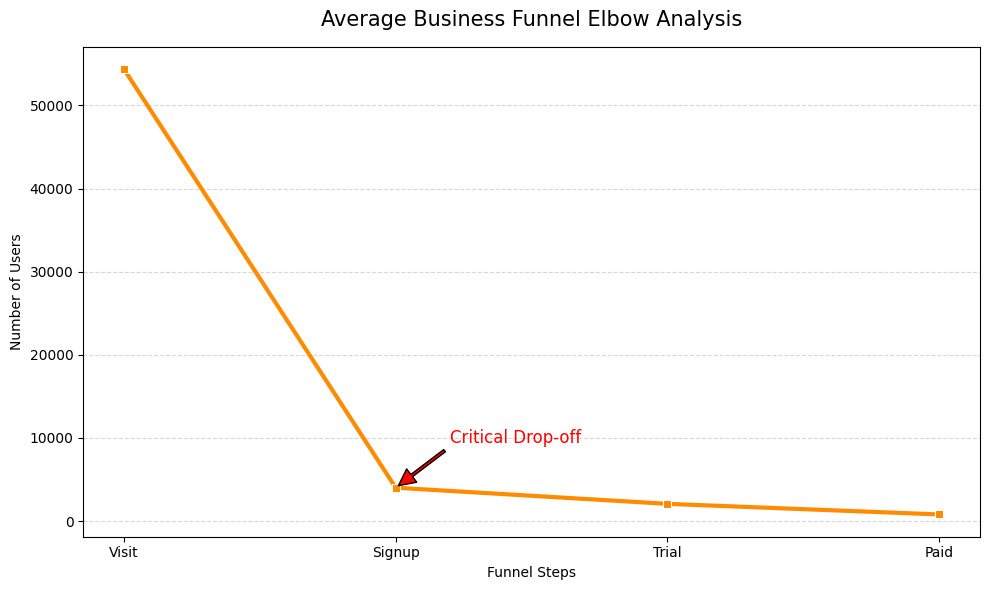

- [ 퍼널 단계별 평균 유저 수 ] -
Visit: 54375명
Signup: 4011명
Trial: 2067명
Paid: 791명

- [ 퍼널 단계별 이탈률 ] -
Visit -> Signup: 92.62%
Signup -> Trial: 48.46%
Trial -> Paid: 61.70%


In [21]:
# funnel_summary 단계별 이탈율 계산, 시각화 및 엘보우 포인트 표시

steps = ['Visit', 'Signup', 'Trial', 'Paid']
avg_values = [
    funnel_summary['방문 유저 수'].mean(),
    funnel_summary['회원가입 유저'].mean(),
    funnel_summary['무료 체험 유저'].mean(),
    funnel_summary['유료 결제 유저'].mean()
]

drop_off_rates = []
for i in range(len(avg_values) - 1):
    rate = (avg_values[i] - avg_values[i+1]) / avg_values[i]
    drop_off_rates.append(rate)

plt.figure(figsize=(10, 6))
sns.lineplot(x=steps, y=avg_values, marker='s', color='darkorange', linewidth=3)

drop_offs = np.abs(np.diff(avg_values))
elbow_idx = np.argmax(drop_offs) + 1 

plt.annotate(f'Critical Drop-off', 
             xy=(elbow_idx, avg_values[elbow_idx]),
             xytext=(elbow_idx + 0.2, avg_values[elbow_idx] + max(avg_values)*0.1),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2),
             fontsize=12, color='red')

plt.title("Average Business Funnel Elbow Analysis", fontsize=15, pad=15)
plt.xlabel("Funnel Steps")
plt.ylabel("Number of Users")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("- [ 퍼널 단계별 평균 유저 수 ] -")
for step, val in zip(steps, avg_values):
    print(f"{step}: {int(val)}명")

print("\n- [ 퍼널 단계별 이탈률 ] -")
for i in range(len(drop_off_rates)):
    print(f"{steps[i]} -> {steps[i+1]}: {drop_off_rates[i]*100:.2f}%")


In [22]:
# funnel_summary 분석 결과 방문 -> 회원가입 단계에서의 이탈률이 92.62%로 가장 높음
# 많은 방문자에 비해 가입으로 넘어가는 단계에서 엘보우 포인트가 발생함
# 회원가입 양식이나 방법이 너무 복잡하기 때문은 아닌지 landing_event_log와의 연계를 통한 확인 필요

# 가입 -> 무료체험 에서는 가입 후 무엇을 체험해봐야 할지에 대해 불명확 한 건 아닌지

# 무료체험 -> 유료전환 에서는 가격 대비 성능이 좋지 않거나 매력적인 기능이 없는건지

/tmp/ipykernel_16/1639930955.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y=col_value, data=df_sorted,
/tmp/ipykernel_16/1639930955.py:22: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/1639930955.py:22: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


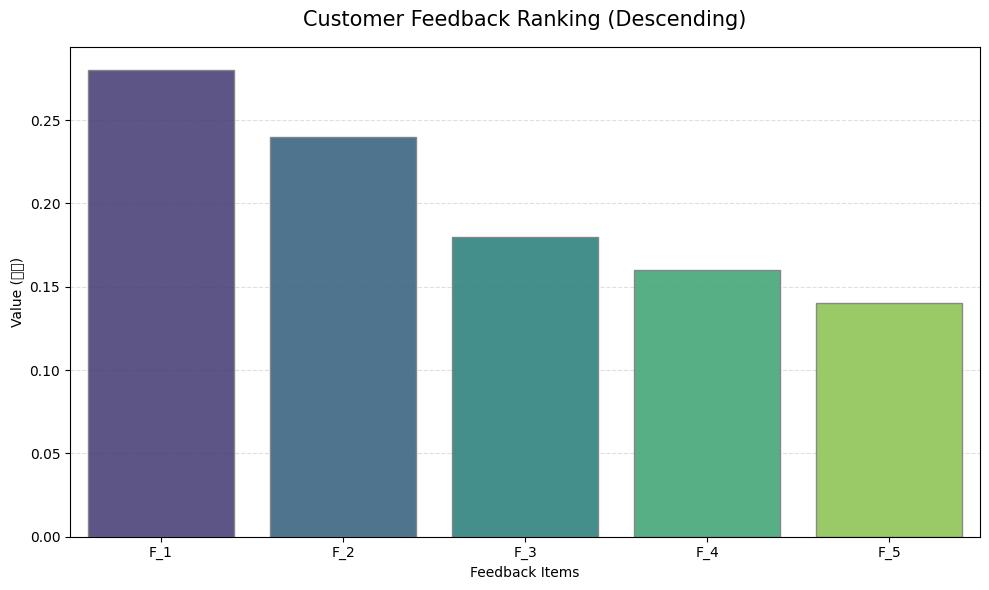

- [ 피드백 유형별 비중 ] -
F_1(가입 절차 번거로움): 28.00%
F_2(무료체험 가치 체감 부족): 24.00%
F_3(요금제 이해 어려움): 18.00%
F_4(팀 기능 이해 부족): 16.00%
F_5(알림 과다): 14.00%


In [23]:
#customer_feedback_summary 데이터 시각화 및 유형별 데이터 연관설 가설 수립

col_category = customer_feedback_summary.columns[0]
col_value = customer_feedback_summary.columns[1]

df_sorted = customer_feedback_summary.sort_values(by=col_value, ascending=False).reset_index(drop=True)
df_sorted['Label'] = [f"F_{i+1}" for i in range(len(df_sorted))]

plt.figure(figsize=(10, 6))

sns.barplot(x='Label', y=col_value, data=df_sorted, 
            palette='viridis', alpha=0.9, edgecolor='gray')

plt.title("Customer Feedback Ranking (Descending)", fontsize=15, pad=15)
plt.xlabel("Feedback Items")
plt.ylabel(f"Value ({col_value})")
plt.xticks(ticks=range(len(df_sorted)), labels=df_sorted['Label'])

plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("- [ 피드백 유형별 비중 ] -")
total_val = df_sorted[col_value].sum()
for i, row in df_sorted.iterrows():
    share = (row[col_value] / total_val) * 100
    print(f"{row['Label']}({row[col_category]}): {share:.2f}%")

In [24]:
# customer_feedback_summary 분석결과 F_1 '가입 절차 번거로움'이 전체의 28%로 가장 높은 비중 차지함
# 이는 funnel_summary에서 나타난 '회원가입 유저'와 연관이 있어보임
# 또한 landing_event_log에서의 과정과 높은 연관이 있어보임
# F_2 '무료체험 가치 체감 부족'은 trial_usage_summary에서 어떠한 기능이 매력적이고 매력적이지 않은지 확인 필요함
# F_3 '요금제 이해 어려움'은 funnel_summary에서 유료 회원 전환율에 대해 문제를 일으킬 것으로 생각됨
# F_4 '팀 기능 이해 부족'은 segment_retention에서 팀 단위 협업 툴로서의 가치가 낮은지 확인해봐야함
# F_5 '알림 과다'는 다른 데이터와의 명확한 연관성을 찾지 못 하여 이에 대해 논의해봐야 할 것 같음

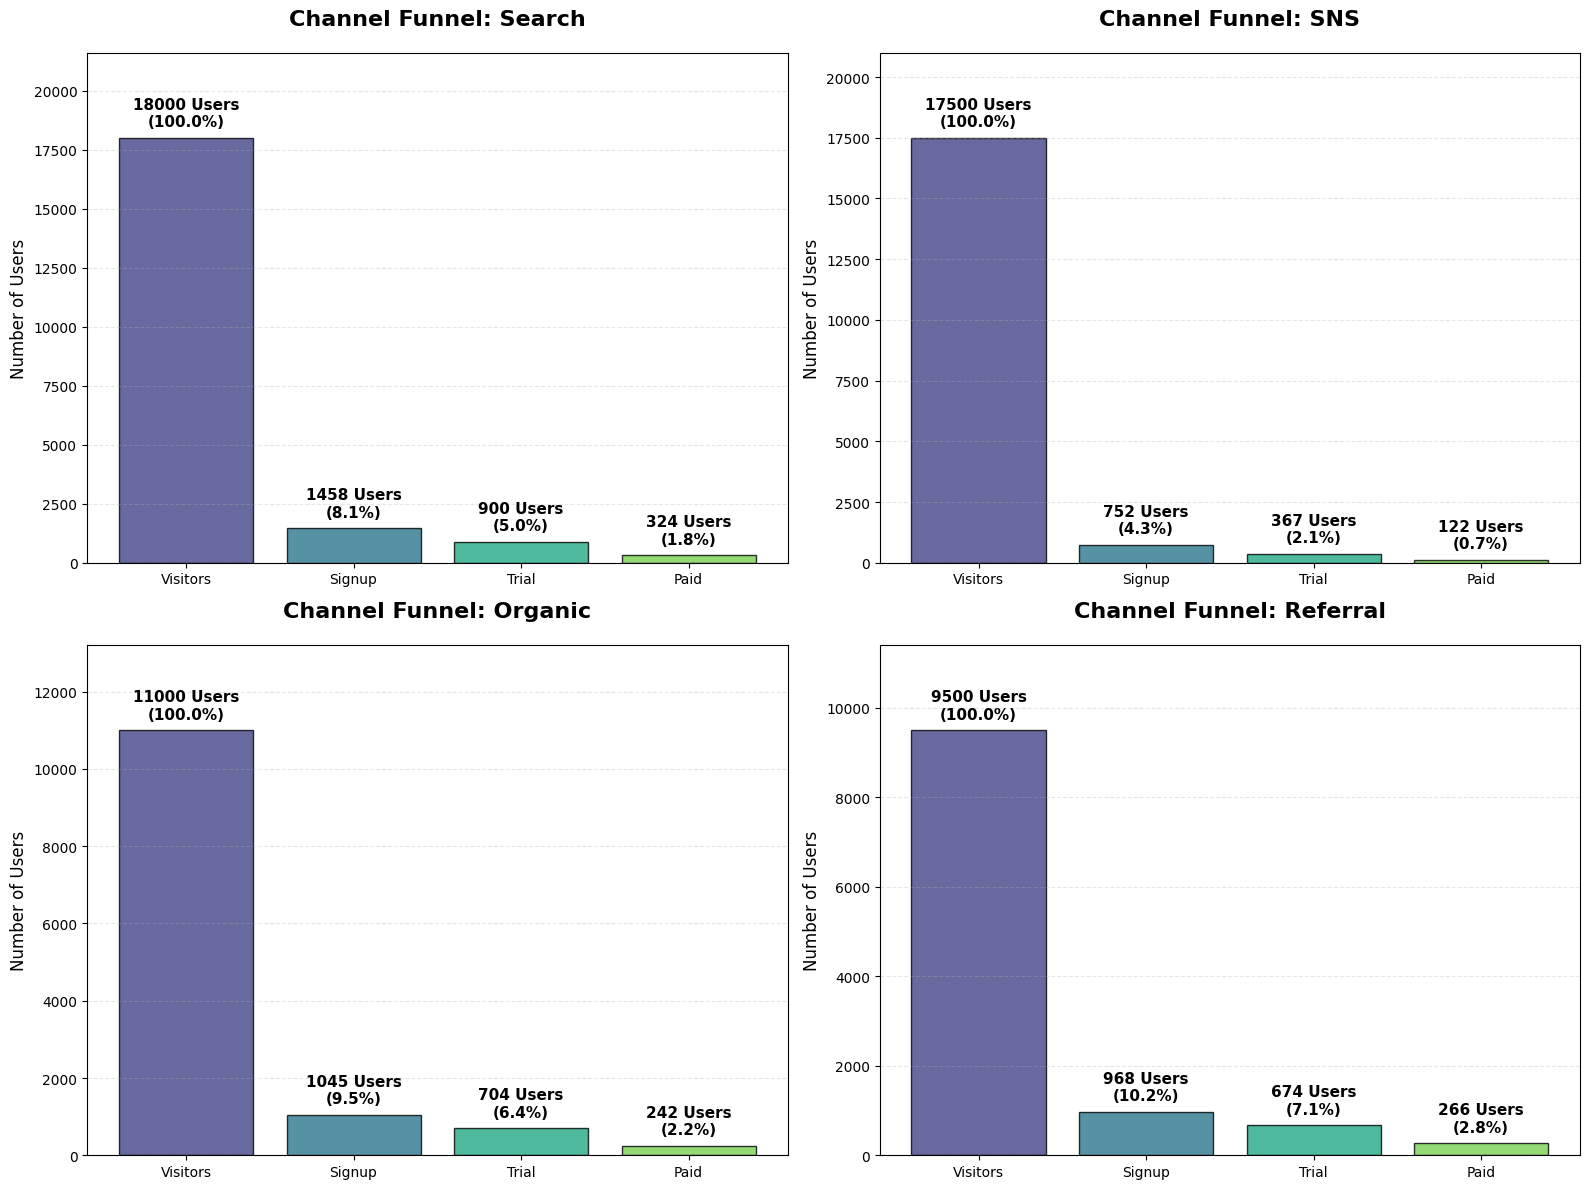

 [ 유입 채널별 퍼널 유지 및 전환 포인트 분석 ]
채널: Search
   체험->결제 구간에서 가장 많은 이탈이 발생하고 있음
--------------------------------------------------
채널: SNS
   가입->체험 구간에서 가장 많은 이탈이 발생하고 있음
--------------------------------------------------
채널: Organic
   체험->결제 구간에서 가장 많은 이탈이 발생하고 있음
--------------------------------------------------
채널: Referral
   체험->결제 구간에서 가장 많은 이탈이 발생하고 있음
--------------------------------------------------


In [25]:
channel_names = ['Search', 'SNS', 'Organic', 'Referral']

steps = ['Visitors', 'Signup', 'Trial', 'Paid']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(channel_names):
    row = channel_performance.iloc[i] 
    
    v = row.iloc[-4] # Visitors
    s_r = row.iloc[-3] # Signup Rate
    t_r = row.iloc[-2] # Trial Rate
    p_r = row.iloc[-1] # Paid Rate
    
    vals = [v, v * s_r, v * t_r, v * p_r]
    rates = [100.0, s_r * 100, t_r * 100, p_r * 100]
  
    colors = sns.color_palette("viridis", 4)
    bars = axes[i].bar(steps, vals, color=colors, alpha=0.8, edgecolor='black')
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + (max(vals)*0.02),
                f'{int(height)} Users\n({rates[j]:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    axes[i].set_title(f"Channel Funnel: {name}", fontsize=16, fontweight='bold', pad=20)
    axes[i].set_ylabel("Number of Users", fontsize=12)
    axes[i].set_ylim(0, max(vals) * 1.2) # 텍스트 공간 확보
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(" [ 유입 채널별 퍼널 유지 및 전환 포인트 분석 ]")

for i, name in enumerate(channel_names):
    row = channel_performance.iloc[i]
    s_r, t_r, p_r = row.iloc[-3], row.iloc[-2], row.iloc[-1]
    
    print(f"채널: {name}")
 
    drop_points = {"가입->체험": s_r - t_r, "체험->결제": t_r - p_r}
    worst_drop = max(drop_points, key=drop_points.get)
    print(f"   {worst_drop} 구간에서 가장 많은 이탈이 발생하고 있음")
    print("-" * 50)

In [26]:
# 각 유입 채널별, 가장 많은 이탈이 발생하는 구간 분석
# '검색'은 무료체험 -> 유료전환 구간에서 가장 많은 이탈이 발생함
# 이는 유료로 전환해야할 매력을 충분히 느끼지 못한 것으로 보임
# 'SNS'는 회원가입 -> 무료체험 구간에서 가장 많은 이탈이 발생함
# 이는 가입 직후 무엇을 해봐야할지에 대해 불명확하거나 막상 가입해보니 복잡하거나 광고와 달라 흥미를 잃은 경우로 보임
# '자연유입'은 무료체험 -> 유료전환 구간에서 가장 많은 이탈이 발생함
# 이는 무료체험 이후 실제 만족할만한 서비스를 제공받지 못한것으로 보임
# '지인추천'은 무료체험 -> 유료전환 구간에 가장 많은 이탈이 발생함
# 이는 추천한 지인에게는 좋은 툴이었으나 본인에게는 맞지 않은 경우인 것으로 보임

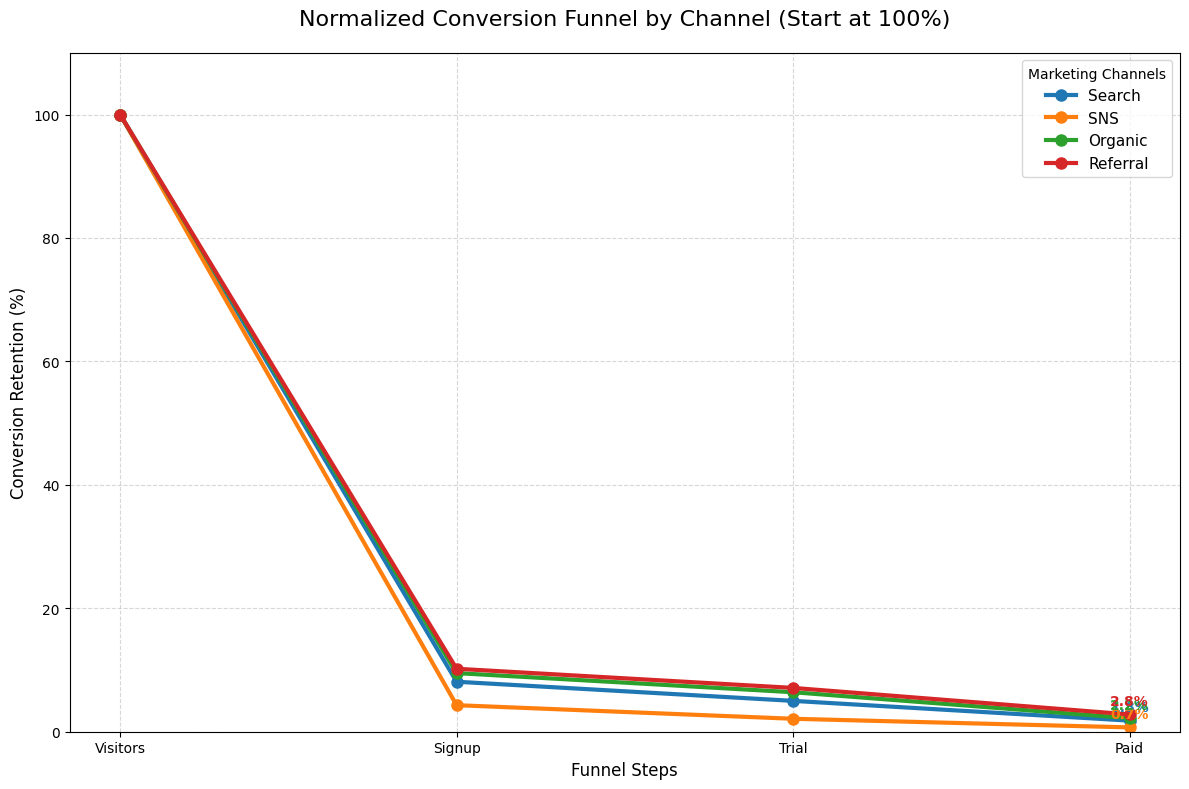

 [ 채널별 전환 이탈률(Drop-off) 비교 분석 ]
▶ 가장 안 떨어지는 채널 : [Referral] (2.8%)

▶ 가장 많이 떨어지는 채널 : [SNS] (0.7%)


In [27]:
c_name = channel_performance.columns[0]
steps = ['Visitors', 'Signup', 'Trial', 'Paid']

plt.figure(figsize=(12, 8))

channel_labels = ['Search', 'SNS', 'Organic', 'Referral']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # 각 채널별 고유 색상

for i, label in enumerate(channel_labels):
    row = channel_performance.iloc[i]
    y_values = [100.0, row.iloc[-3]*100, row.iloc[-2]*100, row.iloc[-1]*100]
    plt.plot(steps, y_values, marker='o', markersize=8, linewidth=3, label=label, color=colors[i])
    plt.text(steps[-1], y_values[-1] + 1, f'{y_values[-1]:.1f}%', 
             ha='center', va='bottom', fontweight='bold', color=colors[i])

plt.title('Normalized Conversion Funnel by Channel (Start at 100%)', fontsize=16, pad=20)
plt.ylabel('Conversion Retention (%)', fontsize=12)
plt.xlabel('Funnel Steps', fontsize=12)
plt.ylim(0, 110) 
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(title='Marketing Channels', fontsize=11)

plt.tight_layout()
plt.show()

print(" [ 채널별 전환 이탈률(Drop-off) 비교 분석 ]")

results = []
for i, label in enumerate(channel_labels):
    row = channel_performance.iloc[i]
    final_rate = row.iloc[-1] * 100
    results.append((label, final_rate))

results.sort(key=lambda x: x[1], reverse=True)

print(f"▶ 가장 안 떨어지는 채널 : [{results[0][0]}] ({results[0][1]:.1f}%)")
print(f"\n▶ 가장 많이 떨어지는 채널 : [{results[-1][0]}] ({results[-1][1]:.1f}%)")

In [28]:
# 채널중 가장 이탈률이 안 떨어지는 채널과 가장 많이 떨어지는 채널 분석
# '지인 추천'은 유입 시점부터 추천한 지인으로부터 서비스의 가치를 설명받았기 때문으로 생각됨
# 이를 늘리기 위해선 만족할만한 서비스 자체의 가치를 높이는것이 중요
# 'SNS'는 광고를 보고 우연히 유입되었으나 흥미가 떨어져 나가버리기 가장 많이 떨어진다고 생각됨
# 이를 늘리기 위해선 광고의 타겟팅을 명확히 하거나 랜딩 페이지를 가입이 아닌 서비스 전달 위주로 바꿔야한다 생각됨